In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0


In [ ]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle


In [ ]:

!kaggle datasets download -d imsparsh/flowers-dataset

Dataset URL: https://www.kaggle.com/datasets/imsparsh/flowers-dataset
License(s): CC0-1.0
100% 205M/205M [00:01<00:00, 182MB/s]



In [ ]:
import zipfile
import os

zip_path    = "/content/flowers-dataset.zip"   # path where you uploaded the zip
extract_dir = "/content/flowers"               # where to extract

# Unzip
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

print("Extracted files:")
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 2:   # stop printing deep file lists
        break

Extracted files:
flowers/
  train/
    dandelion/


In [ ]:
DATA_DIR    = "/content/flowers/train"
IMG_SIZE    = 224
BATCH_SIZE  = 32
SEED        = 42

train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes     : {CLASS_NAMES}")
print(f"Train batches: {len(train_ds)}")
print(f"Val batches  : {len(val_ds)}")

Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Found 2746 files belonging to 5 classes.
Using 549 files for validation.
Classes     : ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Train batches: 69
Val batches  : 18


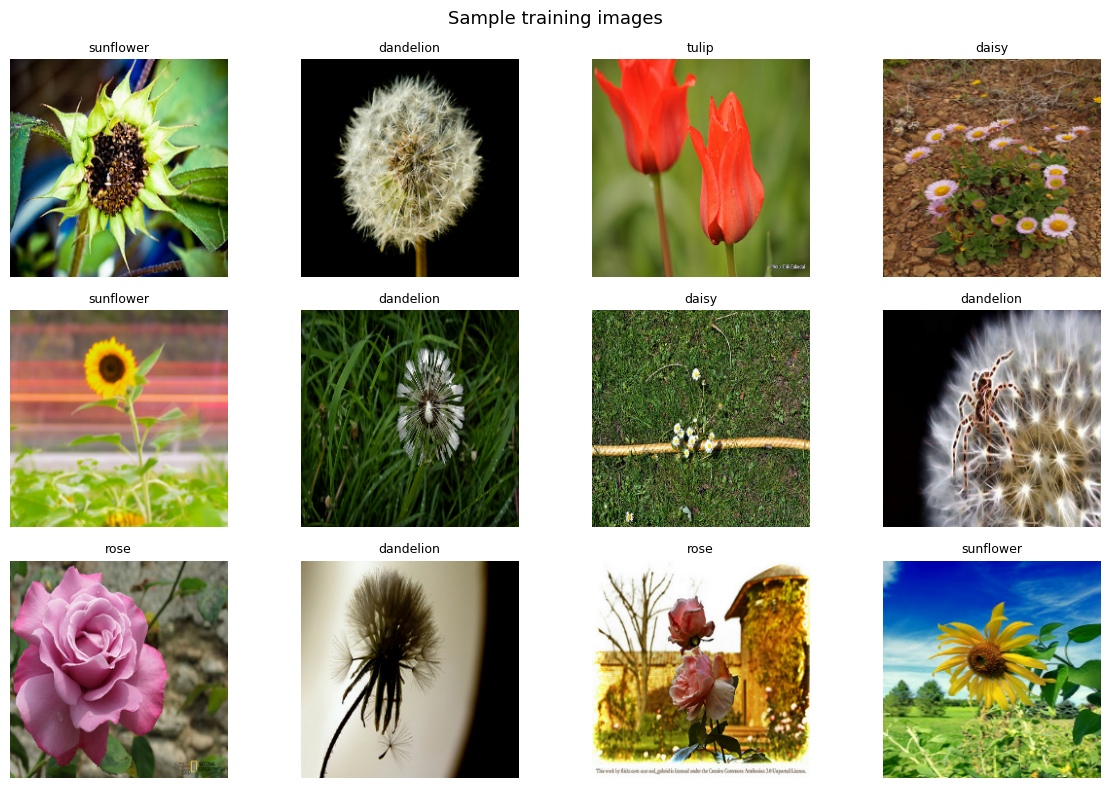

In [ ]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[labels[i]], fontsize=9)
        plt.axis("off")
plt.suptitle("Sample training images", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="augmentation")

def prepare(ds, augment_data=False):
    if augment_data:
        ds = ds.map(lambda x, y: (augment(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = prepare(train_ds, augment_data=True)
val_ds   = prepare(val_ds,   augment_data=False)

print("Pipeline ready.")

Pipeline ready.


In [ ]:
def build_model(num_classes):
    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = keras.applications.efficientnet.preprocess_input(inputs)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="flower_classifier")

model = build_model(NUM_CLASSES)
model.summary()

total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f"\nTrainable params : {trainable:,}  ← head only")
print(f"Frozen params    : {total - trainable:,}  ← backbone")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "flower_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Trainable params : 164,613  ← head only
Frozen params    : 4,049,571  ← backbone


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint("best_phase1.keras", monitor="val_accuracy",
                                     save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                       patience=3, verbose=1),
]

print("=== Phase 1: Training head (backbone frozen) ===")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
)

=== Phase 1: Training head (backbone frozen) ===
Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.6017 - loss: 0.9930
Epoch 1: val_accuracy improved from None to 0.87978, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.7278 - loss: 0.7218 - val_accuracy: 0.8798 - val_loss: 0.3262 - learning_rate: 0.0010
Epoch 2/20
68/69 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.8534 - loss: 0.3706
Epoch 2: val_accuracy improved from 0.87978 to 0.89617, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 86s 574ms/step - accuracy: 0.8548 - loss: 0.3772 - val_accuracy: 0.8962 - val_loss: 0.2852 - learning_rate: 0.0010
Epoch 3/20
68/69 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.8833 - loss: 0.3013
Epoch 3: val_accuracy improved from 0.89617 to 0.91075, saving model to best_phase1.keras

Epoch 3: finished saving model to bes

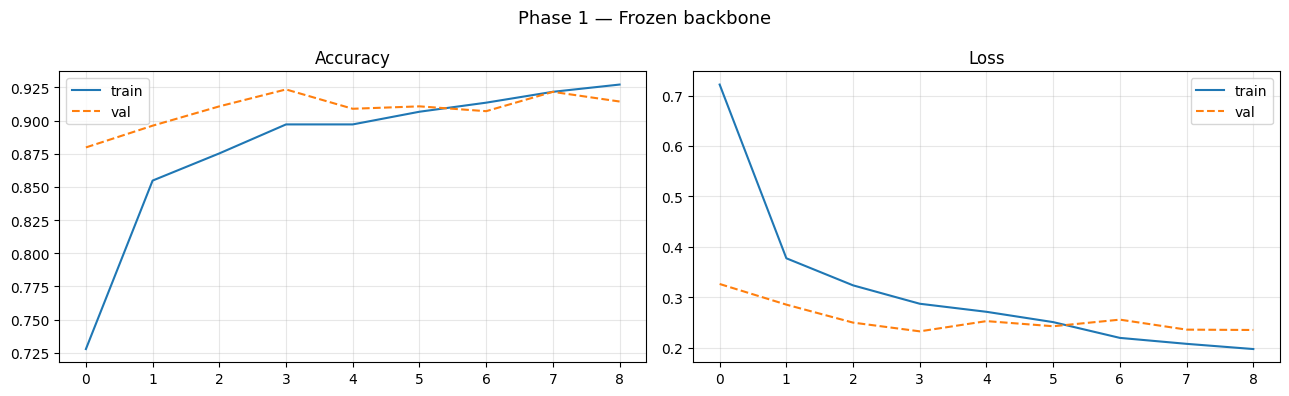

In [ ]:
def plot_history(history, title="Training"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(history.history["accuracy"],     label="train")
    ax1.plot(history.history["val_accuracy"], label="val", linestyle="--")
    ax1.set_title("Accuracy"); ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history["loss"],     label="train")
    ax2.plot(history.history["val_loss"], label="val", linestyle="--")
    ax2.set_title("Loss"); ax2.legend(); ax2.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history(history1, "Phase 1 — Frozen backbone")

In [ ]:
# Unfreeze top 20 layers of backbone
backbone = model.get_layer("efficientnetb0")
backbone.trainable = True

for layer in backbone.layers[:-20]:
    layer.trainable = False

# Recompile with very small LR
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks2 = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=7,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint("best_phase2.keras", monitor="val_accuracy",
                                     save_best_only=True, verbose=1),
]

print("=== Phase 2: Fine-tuning top 20 backbone layers ===")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks2,
)

=== Phase 2: Fine-tuning top 20 backbone layers ===
Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.8156 - loss: 0.5245
Epoch 1: val_accuracy improved from None to 0.90528, saving model to best_phase2.keras

Epoch 1: finished saving model to best_phase2.keras
69/69 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.8143 - loss: 0.5331 - val_accuracy: 0.9053 - val_loss: 0.2751
Epoch 2/20
68/69 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8468 - loss: 0.4477
Epoch 2: val_accuracy did not improve from 0.90528
69/69 ━━━━━━━━━━━━━━━━━━━━ 43s 607ms/step - accuracy: 0.8439 - loss: 0.4697 - val_accuracy: 0.8980 - val_loss: 0.3094
Epoch 3/20
68/69 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.8569 - loss: 0.4350
Epoch 3: val_accuracy did not improve from 0.90528
69/69 ━━━━━━━━━━━━━━━━━━━━ 43s 607ms/step - accuracy: 0.8566 - loss: 0.4349 - val_accuracy: 0.8925 - val_loss: 0.3255
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.8650 - loss: 0.4120
Epoch 4: v

Final Validation Accuracy: 0.9053

              precision    recall  f1-score   support

       daisy       0.92      0.88      0.90        83
   dandelion       0.94      0.93      0.94       137
        rose       0.86      0.88      0.87       103
   sunflower       0.93      0.96      0.94        93
       tulip       0.88      0.87      0.88       133

    accuracy                           0.91       549
   macro avg       0.91      0.91      0.91       549
weighted avg       0.91      0.91      0.91       549



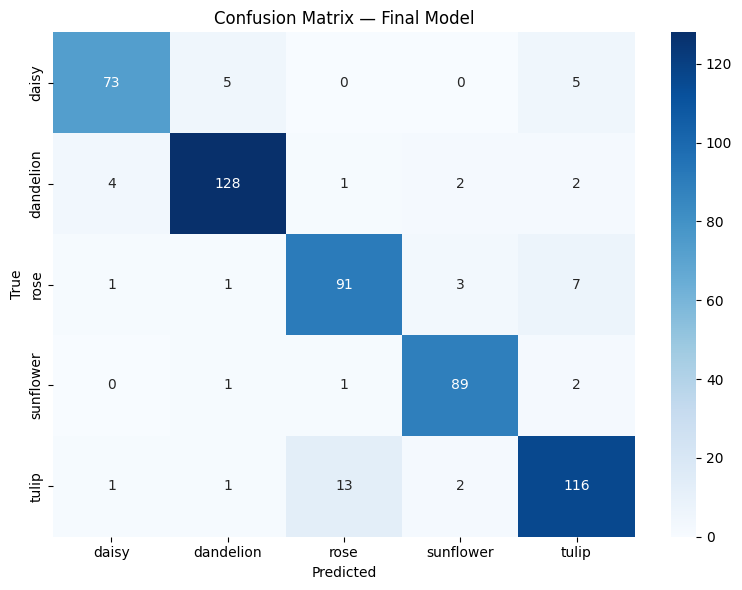

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.models import load_model

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Final Validation Accuracy: {np.mean(y_true == y_pred):.4f}\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Final Model")
plt.tight_layout()
plt.show()

Testing with: tulip → 14487712670_aebe715525_m.jpg


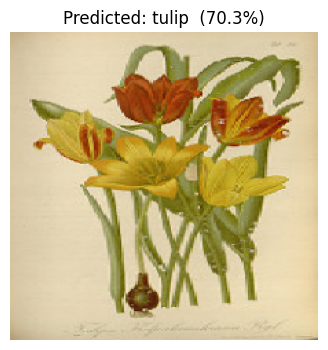


All class probabilities:
  daisy        0.053  ██
  dandelion    0.060  ██
  rose         0.118  ████
  sunflower    0.066  ██
  tulip        0.703  ████████████████████████████


In [ ]:
def predict_image(img_path):
    img = keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds    = model.predict(img_array, verbose=0)[0]
    top_idx  = np.argmax(preds)

    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.title(f"Predicted: {CLASS_NAMES[top_idx]}  ({preds[top_idx]:.1%})", fontsize=12)
    plt.axis("off")
    plt.show()

    print("\nAll class probabilities:")
    for name, prob in zip(CLASS_NAMES, preds):
        bar = "█" * int(prob * 40)
        print(f"  {name:<12} {prob:.3f}  {bar}")

# ── Test with any flower image from the dataset ──
# Pick any image path from your dataset
import random

# Get a random image path from val set
sample_class = random.choice(CLASS_NAMES)
sample_dir   = f"/content/flowers/train/{sample_class}"
sample_img   = random.choice(os.listdir(sample_dir))
sample_path  = f"{sample_dir}/{sample_img}"

print(f"Testing with: {sample_class} → {sample_img}")
predict_image(sample_path)

Upload a flower image:


Saving testing image1.jpeg to testing image1.jpeg


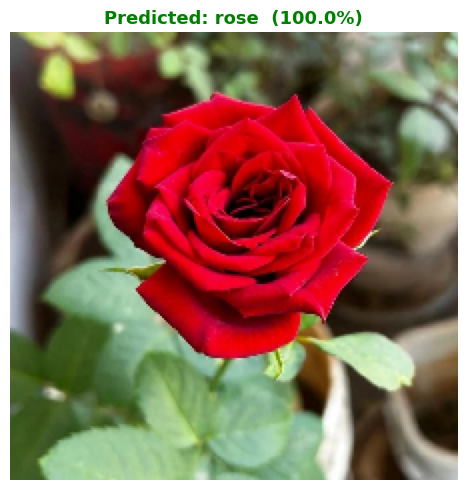


Image      : testing image1.jpeg
Prediction : rose
Confidence : 100.0%

All probabilities:
  daisy        0.000  
  dandelion    0.000  
  rose         1.000  ███████████████████████████████████████
  sunflower    0.000  
  tulip        0.000  


In [ ]:
from google.colab import files
from IPython.display import display
import ipywidgets as widgets

# Upload any flower image from your computer
print("Upload a flower image:")
uploaded = files.upload()

# Get the uploaded file path
img_path = list(uploaded.keys())[0]

# Predict
img = keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

preds   = model.predict(img_array, verbose=0)[0]
top_idx = np.argmax(preds)

# Display image with prediction
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Predicted: {CLASS_NAMES[top_idx]}  ({preds[top_idx]:.1%})",
          fontsize=13, fontweight="bold", color="green")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"\nImage      : {img_path}")
print(f"Prediction : {CLASS_NAMES[top_idx]}")
print(f"Confidence : {preds[top_idx]:.1%}")
print("\nAll probabilities:")
for name, prob in zip(CLASS_NAMES, preds):
    bar = "█" * int(prob * 40)
    print(f"  {name:<12} {prob:.3f}  {bar}")

Upload a flower image:


Saving testing image.jpeg to testing image.jpeg


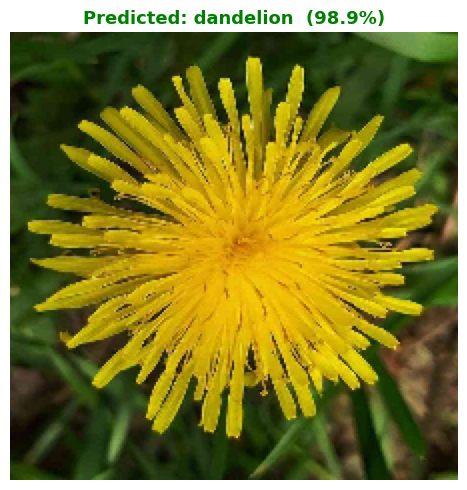


Image      : testing image.jpeg
Prediction : dandelion
Confidence : 98.9%

All probabilities:
  daisy        0.001  
  dandelion    0.989  ███████████████████████████████████████
  rose         0.000  
  sunflower    0.008  
  tulip        0.001  


In [ ]:
from google.colab import files
from IPython.display import display
import ipywidgets as widgets

# Upload any flower image from your computer
print("Upload a flower image:")
uploaded = files.upload()

# Get the uploaded file path
img_path = list(uploaded.keys())[0]

# Predict
img = keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

preds   = model.predict(img_array, verbose=0)[0]
top_idx = np.argmax(preds)

# Display image with prediction
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Predicted: {CLASS_NAMES[top_idx]}  ({preds[top_idx]:.1%})",
          fontsize=13, fontweight="bold", color="green")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"\nImage      : {img_path}")
print(f"Prediction : {CLASS_NAMES[top_idx]}")
print(f"Confidence : {preds[top_idx]:.1%}")
print("\nAll probabilities:")
for name, prob in zip(CLASS_NAMES, preds):
    bar = "█" * int(prob * 40)
    print(f"  {name:<12} {prob:.3f}  {bar}")